# Part 3 - News Classification with LSTM

Multi-class AG News classification using embedding and recurrent neural network models.


## Dataset Download and Execution Instructions

Run this notebook from top to bottom in a Python environment with TensorFlow installed.

Datasets are downloaded automatically:

- *Frankenstein* is downloaded from Project Gutenberg through `tf.keras.utils.get_file`.
- The English-French dataset is downloaded from the ManyThings/Tatoeba Anki collection and limited to 10,000 sentence pairs.
- AG News is downloaded through `tensorflow_datasets`.

Recommended execution environment:

- Python 3.10 or newer.
- TensorFlow 2.15 or newer.
- A GPU is recommended for the full training configuration.

The first LSTM text generation model is intentionally trained for 32 epochs as required. On CPU this can take a long time.

In [9]:
# Global imports and reproducibility setup
import os
import re
import random
import string
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


## Shared Helper Functions

These utility functions keep plotting, text cleaning, and prediction display consistent across the three parts.

In [10]:
def plot_training_curves(history, metrics=("loss", "accuracy"), title_prefix="Model"):
    'Plot training and validation curves from a Keras History object.'
    history_df = pd.DataFrame(history.history)
    available_metrics = [m for m in metrics if m in history_df.columns]
    if not available_metrics:
        available_metrics = ["loss"]

    fig, axes = plt.subplots(1, len(available_metrics), figsize=(6 * len(available_metrics), 4))
    if len(available_metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, available_metrics):
        ax.plot(history_df[metric], label=f"train_{metric}")
        val_metric = f"val_{metric}"
        if val_metric in history_df:
            ax.plot(history_df[val_metric], label=val_metric)
        ax.set_title(f"{title_prefix}: {metric}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.legend()

    plt.tight_layout()
    plt.show()


def normalize_spaces(text):
    'Lowercase text and collapse repeated whitespace.'
    return re.sub(r"\s+", " ", text.lower()).strip()


def clean_sentence(text):
    'Basic sentence cleaning used for translation and classification examples.'
    text = str(text).lower().strip()
    text = re.sub(r"[^a-zA-Z\u00C0-\u00FF?.!,;:'\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Part 3 - News Classification with LSTM

## Objective

This part builds a multi-class classifier for AG News. Each news headline/body text is converted into a padded integer sequence and classified into one of four categories:

1. World
2. Sports
3. Business
4. Sci/Tech

## 3.1 Dataset Loading

AG News is loaded with `tensorflow_datasets`. The official train/test split is used, and part of the training split is reserved for validation.

In [11]:
import tensorflow_datasets as tfds

ag_train_raw, ag_test_raw = tfds.load(
    "ag_news_subset",
    split=["train", "test"],
    as_supervised=True,
)

class_names = ["World", "Sports", "Business", "Sci/Tech"]

train_texts = []
train_labels = []
test_texts = []
test_labels = []

for text_tensor, label_tensor in tfds.as_numpy(ag_train_raw):
    train_texts.append(text_tensor.decode("utf-8"))
    train_labels.append(int(label_tensor))

for text_tensor, label_tensor in tfds.as_numpy(ag_test_raw):
    test_texts.append(text_tensor.decode("utf-8"))
    test_labels.append(int(label_tensor))

train_df = pd.DataFrame({"text": train_texts, "label": train_labels})
test_df = pd.DataFrame({"text": test_texts, "label": test_labels})

print("Train size:", len(train_df))
print("Test size:", len(test_df))
train_df.head()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\MF\tensorflow_datasets\ag_news_subset\incomplete.HBRPOI_1.0.0\ag_news_subset-train.tfrecord…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\MF\tensorflow_datasets\ag_news_subset\incomplete.HBRPOI_1.0.0\ag_news_subset-test.tfrecord-…

Dataset ag_news_subset downloaded and prepared to C:\Users\MF\tensorflow_datasets\ag_news_subset\1.0.0. Subsequent calls will reuse this data.
Train size: 120000
Test size: 7600


,text,label
0,AMD #39;s new dual-core Opteron chip is design...,3
1,Reuters - Major League Baseball\Monday announc...,1
2,President Bush #39;s quot;revenue-neutral quo...,2
3,Britain will run out of leading scientists unl...,3
4,"London, England (Sports Network) - England mid...",1


## 3.2 Text Preprocessing, Tokenization, Vocabulary, and Padding

Text is lowercased and cleaned. A Keras tokenizer builds the vocabulary from training text only. Sentences are converted to integer sequences and padded to a fixed length.

In [12]:
def clean_news_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\s.,!?'-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


MAX_NEWS_WORDS = 30_000
MAX_NEWS_LEN = 120
BATCH_SIZE_NEWS = 128

train_df["clean_text"] = train_df["text"].map(clean_news_text)
test_df["clean_text"] = test_df["text"].map(clean_news_text)

news_tokenizer = keras.preprocessing.text.Tokenizer(
    num_words=MAX_NEWS_WORDS,
    oov_token="<unk>",
)
news_tokenizer.fit_on_texts(train_df["clean_text"])
news_vocab_size = min(MAX_NEWS_WORDS, len(news_tokenizer.word_index) + 1)

x_news_all = keras.preprocessing.sequence.pad_sequences(
    news_tokenizer.texts_to_sequences(train_df["clean_text"]),
    maxlen=MAX_NEWS_LEN,
    padding="post",
    truncating="post",
)
y_news_all = train_df["label"].to_numpy()

x_news_test = keras.preprocessing.sequence.pad_sequences(
    news_tokenizer.texts_to_sequences(test_df["clean_text"]),
    maxlen=MAX_NEWS_LEN,
    padding="post",
    truncating="post",
)
y_news_test = test_df["label"].to_numpy()

val_size = int(0.1 * len(x_news_all))
x_news_train, x_news_val = x_news_all[:-val_size], x_news_all[-val_size:]
y_news_train, y_news_val = y_news_all[:-val_size], y_news_all[-val_size:]

print("Vocabulary size:", news_vocab_size)
print("Train shape:", x_news_train.shape)
print("Validation shape:", x_news_val.shape)
print("Test shape:", x_news_test.shape)

Vocabulary size: 30000
Train shape: (108000, 120)
Validation shape: (12000, 120)
Test shape: (7600, 120)


## 3.3 LSTM Classifier Architecture

The classifier uses an embedding layer, a bidirectional LSTM for stronger context modeling, dropout regularization, and a softmax classifier. Bidirectionality is helpful for classification because the whole text is available before prediction.

In [13]:
NEWS_EMBEDDING_DIM = 128
NEWS_LSTM_UNITS = 128
NEWS_EPOCHS = 6

news_model = keras.Sequential(
    [
        layers.Input(shape=(MAX_NEWS_LEN,)),
        layers.Embedding(news_vocab_size, NEWS_EMBEDDING_DIM, mask_zero=True),
        layers.Bidirectional(layers.LSTM(NEWS_LSTM_UNITS, return_sequences=False)),
        layers.Dropout(0.4),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(len(class_names), activation="softmax"),
    ],
    name="ag_news_bilstm_classifier",
)

news_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

news_model.summary()

Model: "ag_news_bilstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 120, 128)            │       3,840,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,119,876 (15.72 MB)

 Trainable params: 4,119,876 (15.72 MB)

 Non-trainable params: 0 (0.00 B)

## 3.4 Training

The model is trained on the training split and validated on a held-out validation split. Early stopping restores the best validation weights.

In [14]:
news_callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_ag_news_lstm.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=2,
        restore_best_weights=True,
    ),
]

news_history = news_model.fit(
    x_news_train,
    y_news_train,
    validation_data=(x_news_val, y_news_val),
    batch_size=BATCH_SIZE_NEWS,
    epochs=NEWS_EPOCHS,
    callbacks=news_callbacks,
)

Epoch 1/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 234s 274ms/step - accuracy: 0.8674 - loss: 0.3829 - val_accuracy: 0.9065 - val_loss: 0.2752
Epoch 2/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 289s 343ms/step - accuracy: 0.9308 - loss: 0.2109 - val_accuracy: 0.9051 - val_loss: 0.2805
Epoch 3/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 294s 348ms/step - accuracy: 0.9483 - loss: 0.1532 - val_accuracy: 0.9034 - val_loss: 0.3365


## 3.5 Training Curves

Accuracy and loss curves summarize optimization progress and validation behavior.

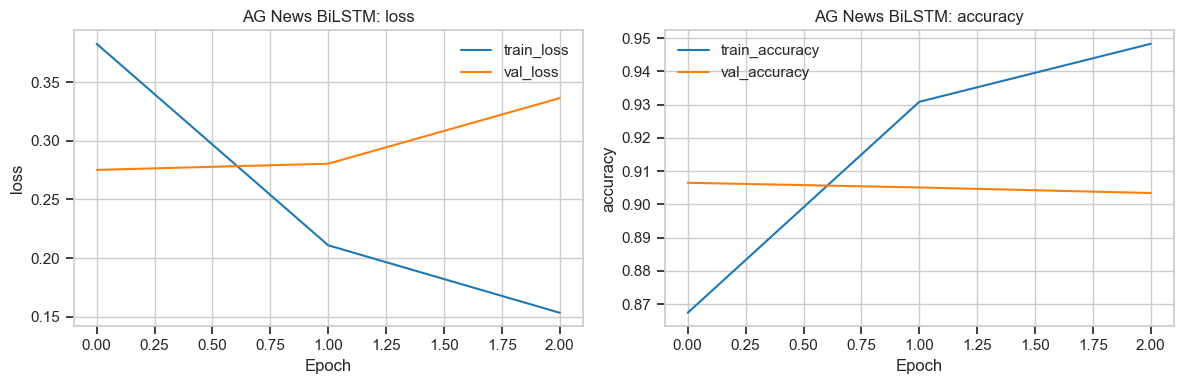

In [15]:
plot_training_curves(news_history, metrics=("loss", "accuracy"), title_prefix="AG News BiLSTM")

## 3.6 Evaluation: Accuracy, Classification Report, and Confusion Matrix

The test set evaluates final generalization. A classification report shows class-level precision, recall, and F1-score. The confusion matrix shows which categories are commonly confused.

Test loss: 0.2777
Test accuracy: 0.9067
              precision    recall  f1-score   support

       World       0.94      0.88      0.91      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.88      0.85      0.87      1900
    Sci/Tech       0.85      0.91      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



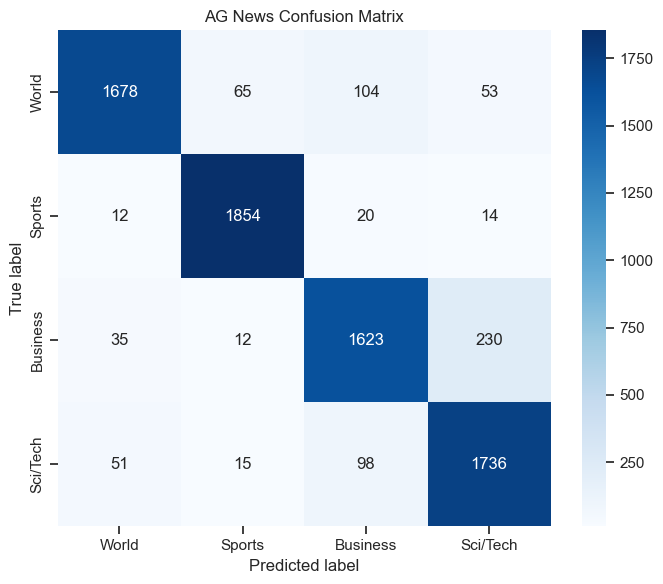

In [16]:
test_loss, test_accuracy = news_model.evaluate(x_news_test, y_news_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

y_news_prob = news_model.predict(x_news_test, batch_size=BATCH_SIZE_NEWS, verbose=0)
y_news_pred = np.argmax(y_news_prob, axis=1)

print(classification_report(y_news_test, y_news_pred, target_names=class_names))

cm = confusion_matrix(y_news_test, y_news_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("AG News Confusion Matrix")
plt.tight_layout()
plt.show()

## 3.7 Error Analysis

Misclassified examples help identify whether the classifier struggles with ambiguous wording, short texts, or categories with overlapping vocabulary.

In [17]:
errors = np.where(y_news_pred != y_news_test)[0]
print("Number of test errors:", len(errors))

for idx in errors[:10]:
    print("Text:", test_df.iloc[idx]["text"])
    print("Expected:", class_names[y_news_test[idx]])
    print("Predicted:", class_names[y_news_pred[idx]])
    print("-" * 80)

Number of test errors: 709
Text: AccountingWEB.com - October 06, 2004 - The opening of a trial related to Oracle #39;s takeover bid of PeopleSoft featured the revelation that CEO Craig Conway was fired last week for making misleading statements about PeopleSoft #39;s sales.
Expected: Business
Predicted: Sci/Tech
--------------------------------------------------------------------------------
Text: Geneva - Worldwide sales of industrial robots surged to record levels in the first half of 2004 after equipment prices fell while labour costs grew, the United Nations Economic Commission for Europe said in a report to be released today.
Expected: Sci/Tech
Predicted: Business
--------------------------------------------------------------------------------
Text: AFP - Microsoft said it will join with India's second-largest software firm, Infosys Technologies, to provide software and consulting to manufacturing, banking and automobile companies.
Expected: World
Predicted: Sci/Tech
-------------

## 3.8 Testing on Custom News Headlines

The trained model can predict labels for new custom headlines.

In [18]:
def predict_news_category(texts):
    cleaned = [clean_news_text(t) for t in texts]
    seqs = news_tokenizer.texts_to_sequences(cleaned)
    padded = keras.preprocessing.sequence.pad_sequences(
        seqs,
        maxlen=MAX_NEWS_LEN,
        padding="post",
        truncating="post",
    )
    probs = news_model.predict(padded, verbose=0)
    labels = np.argmax(probs, axis=1)

    results = []
    for text, label, prob in zip(texts, labels, probs):
        results.append(
            {
                "headline": text,
                "predicted_category": class_names[int(label)],
                "confidence": float(np.max(prob)),
            }
        )
    return pd.DataFrame(results)


custom_headlines = [
    "Global leaders meet to discuss a new climate agreement",
    "The national team wins the championship after a dramatic final",
    "Technology stocks rise as chip demand increases",
    "A new spacecraft sends detailed images from Mars",
]

predict_news_category(custom_headlines)

,headline,predicted_category,confidence
0,Global leaders meet to discuss a new climate a...,World,0.573940
1,The national team wins the championship after ...,Sports,0.908857
2,Technology stocks rise as chip demand increases,Business,0.534207
3,A new spacecraft sends detailed images from Mars,Sci/Tech,0.982595


## 3.9 Bonus Experiments: Dropout, GRU, and Bidirectional LSTM

The main classifier already includes dropout and a bidirectional LSTM. The following compact experiment compares LSTM, GRU, and bidirectional LSTM variants under the same preprocessing setup.

In [19]:
def build_news_variant(cell="lstm", bidirectional=False, dropout_rate=0.3):
    inputs = keras.Input(shape=(MAX_NEWS_LEN,))
    x = layers.Embedding(news_vocab_size, NEWS_EMBEDDING_DIM, mask_zero=True)(inputs)

    if cell == "gru":
        recurrent_layer = layers.GRU(NEWS_LSTM_UNITS)
    else:
        recurrent_layer = layers.LSTM(NEWS_LSTM_UNITS)

    if bidirectional:
        x = layers.Bidirectional(recurrent_layer)(x)
    else:
        x = recurrent_layer(x)

    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(len(class_names), activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model


NEWS_EXPERIMENT_EPOCHS = 2
news_experiment_configs = [
    {"name": "LSTM + dropout", "cell": "lstm", "bidirectional": False, "dropout_rate": 0.3},
    {"name": "GRU + dropout", "cell": "gru", "bidirectional": False, "dropout_rate": 0.3},
    {"name": "Bidirectional LSTM + dropout", "cell": "lstm", "bidirectional": True, "dropout_rate": 0.3},
]

news_experiment_results = []

for cfg in news_experiment_configs:
    print("Running:", cfg["name"])
    model = build_news_variant(
        cell=cfg["cell"],
        bidirectional=cfg["bidirectional"],
        dropout_rate=cfg["dropout_rate"],
    )
    hist = model.fit(
        x_news_train,
        y_news_train,
        validation_data=(x_news_val, y_news_val),
        batch_size=BATCH_SIZE_NEWS,
        epochs=NEWS_EXPERIMENT_EPOCHS,
        verbose=1,
    )
    news_experiment_results.append(
        {
            "model": cfg["name"],
            "final_val_loss": hist.history["val_loss"][-1],
            "final_val_accuracy": hist.history["val_accuracy"][-1],
        }
    )

pd.DataFrame(news_experiment_results).sort_values("final_val_accuracy", ascending=False)

Running: LSTM + dropout
Epoch 1/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 130s 152ms/step - accuracy: 0.8728 - loss: 0.3766 - val_accuracy: 0.9067 - val_loss: 0.2871
Epoch 2/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 127s 150ms/step - accuracy: 0.9284 - loss: 0.2200 - val_accuracy: 0.9018 - val_loss: 0.2943
Running: GRU + dropout
Epoch 1/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 118s 139ms/step - accuracy: 0.8578 - loss: 0.3974 - val_accuracy: 0.9017 - val_loss: 0.2933
Epoch 2/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 117s 138ms/step - accuracy: 0.9280 - loss: 0.2179 - val_accuracy: 0.9035 - val_loss: 0.2964
Running: Bidirectional LSTM + dropout
Epoch 1/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 225s 265ms/step - accuracy: 0.8746 - loss: 0.3621 - val_accuracy: 0.9062 - val_loss: 0.2805
Epoch 2/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 277s 329ms/step - accuracy: 0.9326 - loss: 0.2024 - val_accuracy: 0.9028 - val_loss: 0.2933


,model,final_val_loss,final_val_accuracy
1,GRU + dropout,0.296390,0.903500
2,Bidirectional LSTM + dropout,0.293318,0.902750
0,LSTM + dropout,0.294308,0.901833


# Technical Report - Part 3

## Architecture Choices

The classifier uses an embedding layer followed by a bidirectional LSTM. Bidirectionality is appropriate because the full news text is available at prediction time. Dense and dropout layers produce the final four-class softmax prediction.

## Hyperparameters and Training

- Vocabulary size: 30,000
- Maximum sequence length: 120
- Embedding size: 128
- LSTM units: 128
- Batch size: 128
- Epochs: 6
- Optimizer: Adam
- Loss: sparse categorical cross-entropy

## Evaluation

Evaluation includes test accuracy, classification report, confusion matrix, error analysis, and predictions on custom headlines. Bonus experiments compare LSTM, GRU, and bidirectional LSTM variants with dropout.

## Limitations and Improvements

AG News examples can be ambiguous, especially between Business and Sci/Tech. Improvements include pretrained embeddings, transformer encoders, stronger regularization, hyperparameter search, and calibration analysis.

## Conclusion

The notebook demonstrates a complete LSTM text classification workflow with preprocessing, vocabulary creation, training, evaluation, visualization, and custom testing.

# Requirements

```text
tensorflow>=2.15
tensorflow-datasets>=4.9
numpy>=1.24
pandas>=2.0
matplotlib>=3.7
seaborn>=0.13
scikit-learn>=1.3
jupyter>=1.0
```
